# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [1]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

# Create field & modes of interest following yaml configuration

Initialize coordinate space and system parameters that we will use to define our field.

In [ ]:
index = 0

stream = open(f"configs/ga{index}.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

num_phase_maps_near = cnfg['num_phase_maps_near']
num_phase_maps_far = cnfg['num_phase_maps_far']

num_of_phase_maps = num_phase_maps_near + num_phase_maps_far # Total number of phase maps
instance_name = cnfg['ga_instance'] # directory name of best phases

# Print the instance name (for reference)

print(instance_name)

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = eval(cnfg['rot_angle'])

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

xx,yy=np.meshgrid(X ,Y)

r, phi= cart2pol(xx, yy)

#dr = r[1,0] - r[0,0]
#dphi = phi[1,0] - phi[0,0]

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []

if (num_of_output_chans==2):
    output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=channel_seperation)
else: 
    output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation)

#output_chans = output_chan_triangle(X, Y, output_chan_width, maxx, chan_sep=channel_seperation) # This can only be used if we are explcitly sorting three channels

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        ell, p = LG_modes[ii][0], LG_modes[ii][1]
        field = LG(r, phi, ell, p, w0, h, 0, k)
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))

3phase_30cm_new_GA


We can optionally apply rotations/translations onto the knotted field

In [3]:
# Rotates the incident knot by rot_phi

def create_rotated_knots(rot_phi):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y)
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r, phi= cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs


# Translates the incident knot by x_trans/y_trans

def create_translated_knots(x_trans, y_trans):

    xx,yy=np.meshgrid(X ,Y);
    
    xx_trans = xx + x_trans
    yy_trans = yy + y_trans 

    r, phi= cart2pol(xx_trans,yy_trans)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))

    return list_of_OAMs

Plot the incident field

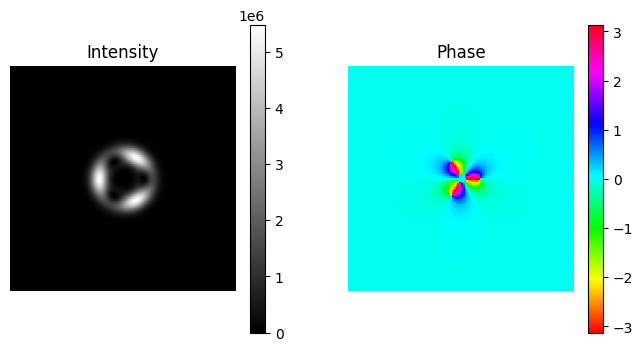

In [4]:
field = norm_field(list_of_OAMs[0].oamBeam, h)
TotInt(field)

Now, prepare the phase maps. This time, we load up the genetic instances

In [5]:
import pickle

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)


Compute phase screens and plot them 

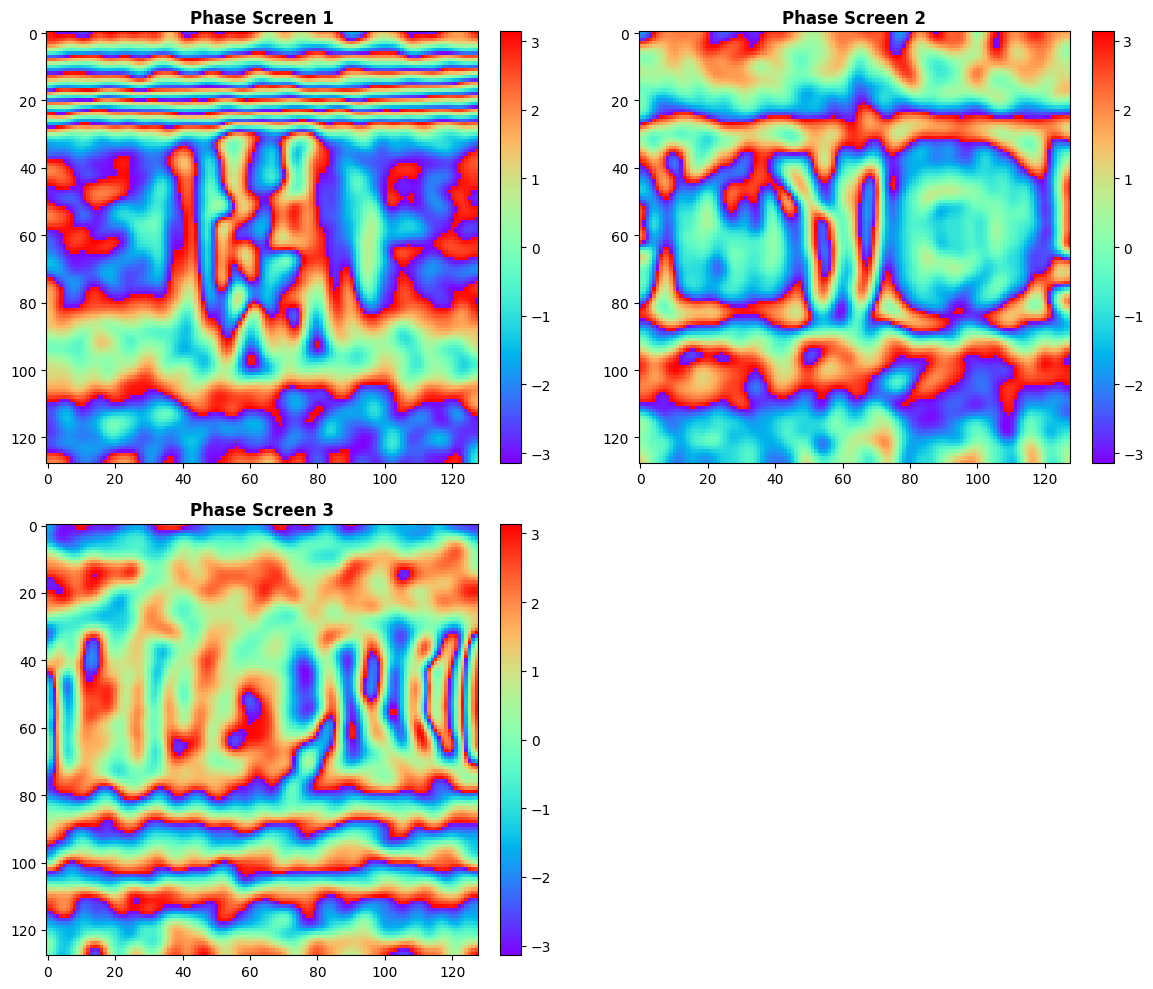

In [6]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

# Compute phase screens and plot them 

for ii in range(num_of_phase_maps):
    # Apply extra gaussian filter on output data 
    phase_maps[ii]= np.exp(1j*phase_out[ii])

# Plot all phase screens in a subplot grid
# Calculate grid dimensions (try to make it as square as possible)
n_cols = int(np.ceil(np.sqrt(num_of_phase_maps)))
n_rows = int(np.ceil(num_of_phase_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))

# Handle case where there's only one phase screen
if num_of_phase_maps == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

# Plot each phase screen
for ps_index in range(num_of_phase_maps):
    im = axes[ps_index].imshow(np.angle(phase_maps[ps_index]), cmap='rainbow')
    axes[ps_index].set_title(f"Phase Screen {ps_index+1}", fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=axes[ps_index], fraction=0.046, pad=0.04)

# Hide any unused subplots
for ps_index in range(num_of_phase_maps, len(axes)):
    axes[ps_index].axis('off')

plt.tight_layout()
plt.show()

# Simulated Experiment

Now, we proceed to compute our chosen, simulated experiment. We can run the experiment from here. 

In [7]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, norm_field
from knot_funcs import propTF

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

Determine the experiment we are going to design

In [8]:
simulateLens = cnfg['simulateLens']
multiPhase = cnfg['multiPhase']
multiPhaseLens = cnfg['multiPhaseLens']

z_o = cnfg['z_o']*cm
fourier_lens = cnfg['fourier_length']

In [9]:
multiPhase

False

Choose the LG beam to analyze

In [10]:
mode_num = 0
field = norm_field(list_of_OAMs[mode_num].oamBeam, h)

# Compute the initial field intensity. Will be important for later

int_knot = np.sum(np.abs(field)**2)

Modulate the beam with the first phase screen (if applicable).

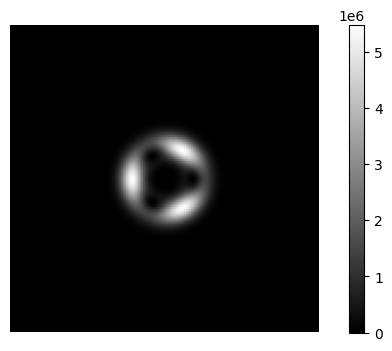

In [11]:
# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

# plot the beam

TotInt(field_mod_1, phase=False)

Depending on what kind of experiment we choose to realize, we may opt to implement multiple phase screens. 

### Multiple Phase Screens only

In this experiment, we simply propagate the beam through multiple phase maps that we opt to optimize

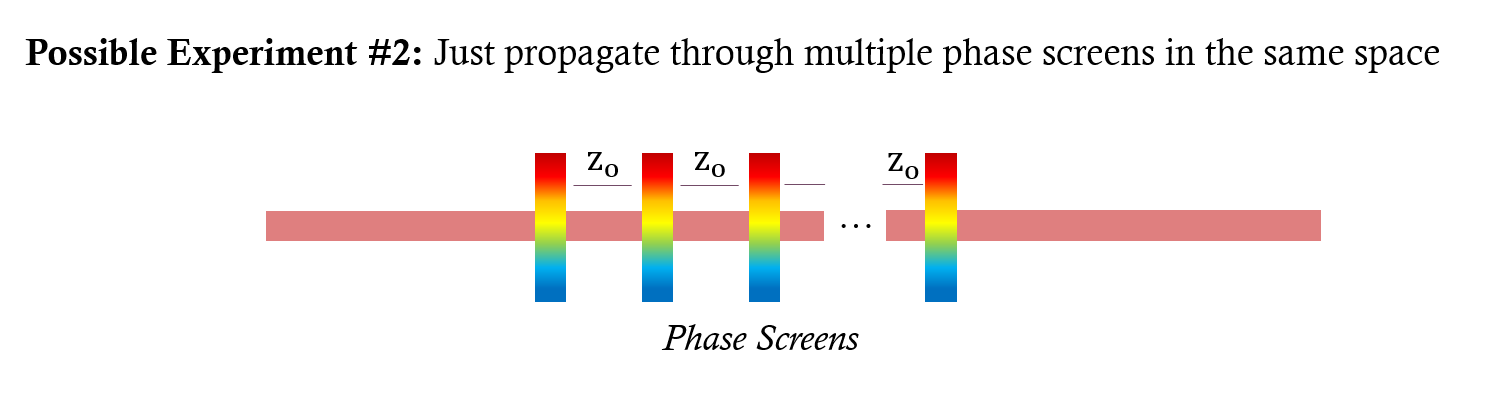

1


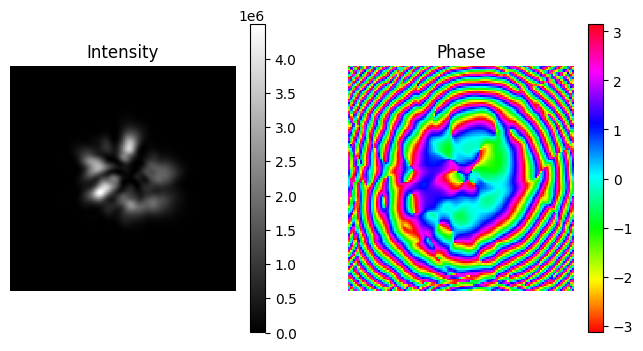

2


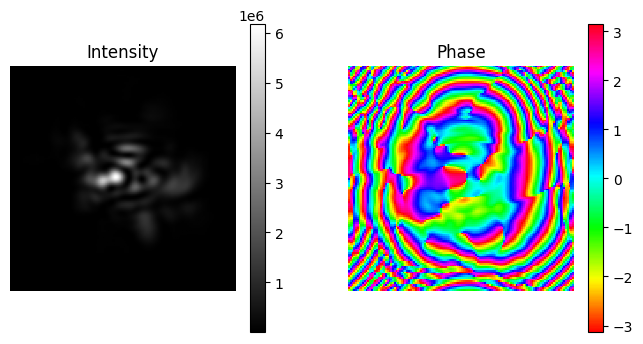

In [147]:
if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for ii in range(1, len(phase_maps)):
                print(ii)
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Plot the beam 
                TotInt(field_after)
                plt.show()
                
                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[ii]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)


At this point, plot the final beam

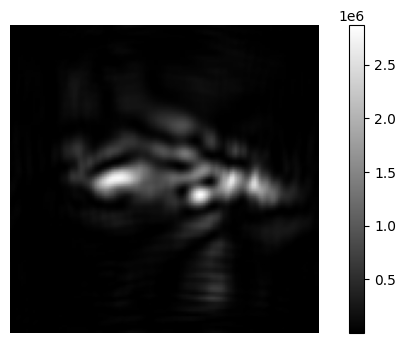

In [148]:
TotInt(final_field, phase=False)

### Multiple Phases with Lens

Alternatively, we create stacks of plates in the near field, then apply a lens (i.e. take the fourier transform)

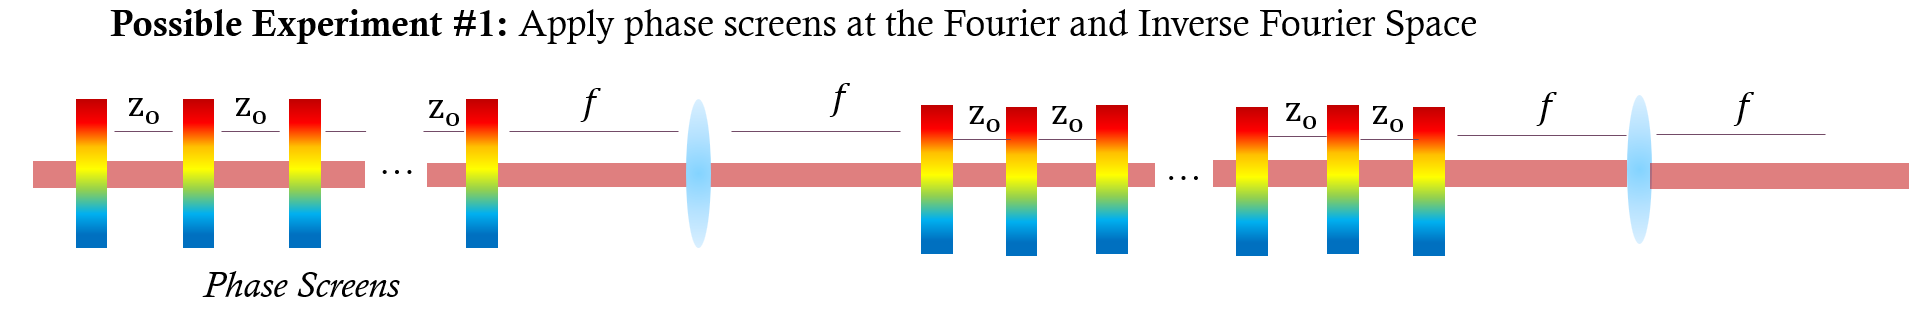

In [12]:
if (multiPhaseLens): # Multi-phase experiment with the lens
        field_after = field_mod_1

        #print(num_phase_maps_near)
        for ii in range(1, num_phase_maps_near):
            # Propagate the beam by a distance z_o 
            field_after = propTF(field_after, maxx, la, z_o)
            # Apply the next phase map in the near field (if applicable)
            field_after = field_after*phase_maps[ii]
                
        # Fourier transform the beam into the far field
        field_lens = fftshift(fft2(field_after))

Plot the field at the first focal plane of the lens

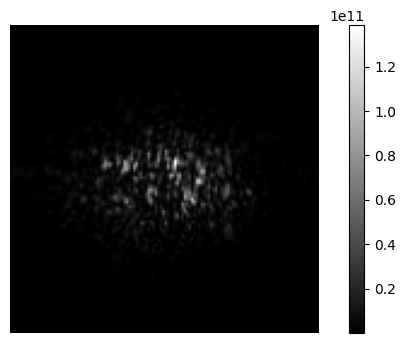

In [13]:
TotInt(field_lens, phase=False)

Now, modulate the beam in the far field (if applicable)

In [14]:
# What happens next depends on whether we have one or two phase maps
        
if (num_phase_maps_far==0):
    # Compute the field intensity 
    final_field = field_lens
        
else:
    # Modulate the field by the first far field map

    print(num_phase_maps_near)
    field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

    if (multiPhaseLens):
        field_after_2 = field_mod_2
        
        #print(1+num_phase_maps_near)
        #print(num_of_phase_maps)

        for jj in range(1+num_phase_maps_near, num_of_phase_maps):
            print(jj)
            # Propagate the beam 
            field_after_2 = propTF(field_after_2, maxx, la, z_o)
            # Apply phase to beam 
            field_after_2 = field_after_2*phase_maps[jj]

        # Apply inverse fourier transform onto beam
        field_lens_2 = ifft2(ifftshift(field_after_2))

    final_field = field_lens_2

Make a plot of the final field

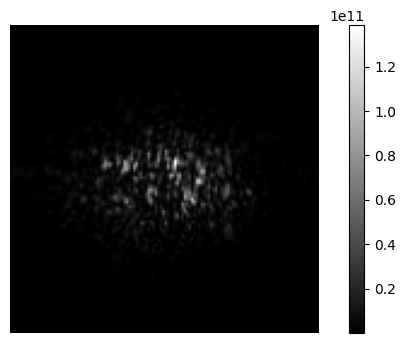

In [15]:
TotInt(final_field, phase=False)

### Standard Experiment 

This is the same procedure that we follow from Robert Fickler's paper, and what we have been doing up until now.
 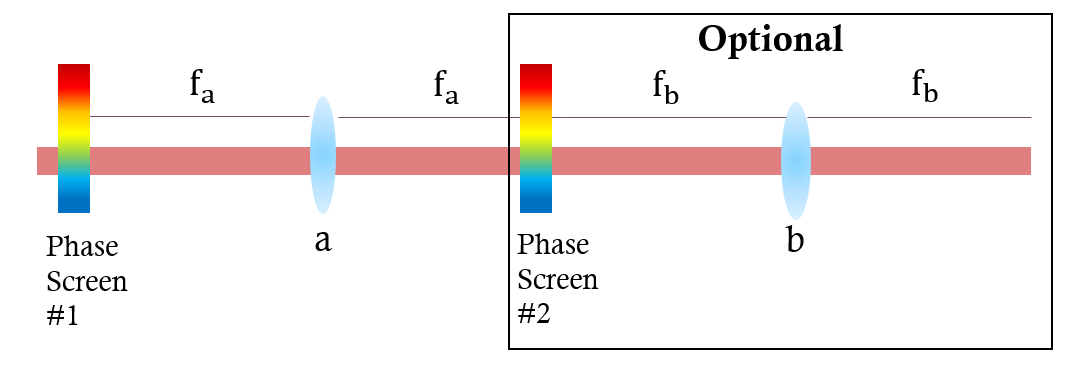

In [39]:
if (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
    field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    
else: # Compute the field at the front focal plane of the lens
    field_lens = fftshift(fft2(field_mod_1))

Make a plot of the field at the focal length of the lens 

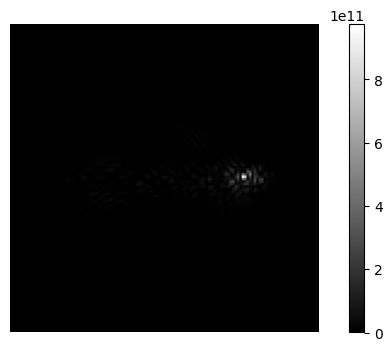

In [12]:
TotInt(field_lens, phase=False)

Simulating the second phase map (if applicable)

In [13]:
if (num_phase_maps_far == 0):
    final_field = field_lens

else:
    field_mod_2 = field_lens*phase_maps[num_phase_maps_near]

    if simulateLens:
        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

    else:
        field_lens_2 = ifft2(ifftshift(field_mod_2))

    final_field = field_lens_2

Make a plot of the field

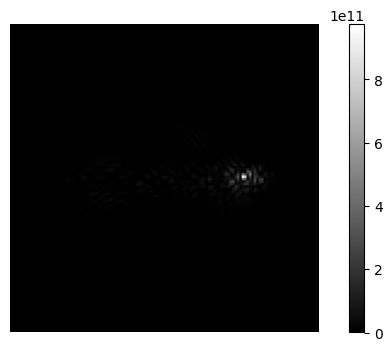

In [14]:
TotInt(final_field, phase=False)

# Crosstalk Matrix

We compute performance metrics of our experiment. We redefine the function that we use to do this here. 

In [12]:
from optical_functions import shannon_entropy
import time

def compute_sorting_performance(phase_maps, list_of_OAMs):
    
    # Make the dimensionality of our sorting in terms of # of modes
    d = len(list_of_OAMs)
    
    # Now, this is the fitness parameter 
    sorting_performance = 0  

    # Actually, let's introduce the crosstalk matrix 
    crosstalk_matrix = np.zeros((num_of_output_chans, num_of_output_chans))
    
    # Let's introduce the secret key rate here, actually. 
    secret_key = 0

    for ii in range(d):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
        
        # Do a proper normalization on the incident field 
        
        field = norm_field(field,h)
        
        # Compute the initial field intensity. This will be important for later
        
        int_knot = np.sum(np.abs(field)**2)
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # Proceed with our chosen experiment

        # Case 1: We are doing the experiment without any lenses

        if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for jj in range(1, len(phase_maps)):
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[jj]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)

        else: # Case 2: We are computing the experiment with the lens 

            if (multiPhaseLens): # Multi-phase experiment with the lens
                field_after = field_mod_1

                for kk in range(1, num_phase_maps_near):
                    # Propagate the beam by a distance z_o 
                    field_after = propTF(field_after, maxx, la, z_o)
                    # Apply the next phase map in the near field (if applicable)
                    field_after = field_after*phase_maps[kk]
                
                # Fourier transform the beam into the far field
                field_lens = fftshift(fft2(field_after))

            elif (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
                field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
        
            
            else: # Compute the field at the front focal plane of the lens
                 field_lens = fftshift(fft2(field_mod_1))
        
            # What happens next depends on whether we have one or two phase maps
        
            if (num_phase_maps_far==0):
                # Compute the field intensity 
                final_field = field_lens
        
            else:
                # Modulate the field by the first far field map
                field_mod_2 = field_lens*phase_maps[num_phase_maps_near]
                if (multiPhaseLens):
                    field_after_2 = field_mod_2
                    
                    for ll in range(1+num_phase_maps_near, num_of_phase_maps):
                        # Propagate the beam 
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        # Apply phase to beam 
                        field_after_2 = field_after_2*phase_maps[ll]
            
                 # Apply inverse fourier transform onto beam
                    field_lens_2 = ifft2(ifftshift(field_after_2))

                 # simulate the lens field again. This is the final field. 
                elif (simulateLens):
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else: 
                    field_lens_2 = ifft2(ifftshift(field_mod_2))

                final_field = field_lens_2
        
        # We normalize the final field and compute the intensity 
        
        final_field = norm_field(final_field,h)
        final_field_int = np.abs(final_field)**2
        
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        # New: to construct our crosstalk matrix, let's store the individual intensities
        incorrect_chan_ints = []
        
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chan_ints.append(np.sum(field_in_pupil)/int_knot)
            incorrect_chans += np.sum(field_in_pupil)/int_knot
            
        # Now, evaluate the sorting performance 
        correct_chans = np.sum(final_field_int*output_chans[ii]) # normalization is mode-specific
        sorting_performance += correct_chans - incorrect_chans
        
        # Compute the detector effeciency 
        detect_eff = correct_chans/int_knot
        crosstalk_matrix[ii,ii] = detect_eff 
        
        # Compute the crosstalk matrix. For more than two modes, we have to be a bit more meticulous with our approach. 
        
        for jj, ind in enumerate(temp_index):
            crosstalk_eff = incorrect_chan_ints[jj]
            crosstalk_matrix[ii, ind] = crosstalk_eff

    #print(crosstalk_matrix)
    # Compute the "QBER" using the off-diagonals of the crosstalk matrix 
    qber = ((d-1)/d**2)*(crosstalk_matrix.sum() - np.trace(crosstalk_matrix)) # This bounds the qber to 1, in principle

    # Compute the secret key rate
    secret_key = np.log2(d) - 2*shannon_entropy(qber,d)
        
    return ((1/d)*sorting_performance), crosstalk_matrix, secret_key

In [13]:
def visualize_input_output_fields(phase_maps, list_of_OAMs, figsize_per_mode=(6, 5), save_path=None, dpi=300):
    """
    Visualize all input fields and output fields in separate subplots.
    Creates two separate figures: one for inputs, one for outputs.
    
    Parameters:
    -----------
    phase_maps : array
        The phase maps used for beam modulation
    list_of_OAMs : list
        List of oamModes objects containing the input beams
    figsize_per_mode : tuple
        Figure size per mode (width, height). Total figure width = width * num_modes
    save_path : str, optional
        Base path to save figures. '_inputs.png' and '_outputs.png' will be appended.
        If None, figures are not saved.
    dpi : int
        Resolution for saved figure (default: 300)
    
    Returns:
    --------
    fig_input, axes_input : Input figure and axes
    fig_output, axes_output : Output figure and axes
    """
    d = len(list_of_OAMs)
    
    # Calculate figure sizes
    fig_width = figsize_per_mode[0] * d
    fig_height = figsize_per_mode[1]
    
    # Create separate figures for input and output
    fig_input, axes_input = plt.subplots(1, d, figsize=(fig_width, fig_height))
    fig_output, axes_output = plt.subplots(1, d, figsize=(fig_width, fig_height))
    
    # Handle case where d=1 (axes won't be an array)
    if d == 1:
        axes_input = [axes_input]
        axes_output = [axes_output]
    
    # Store output fields for plotting
    output_fields = []
    
    for ii in range(d):
        # Get initial field
        field = list_of_OAMs[ii].oamBeam 
        field = norm_field(field, h)
        
        # Plot input field
        input_intensity = np.abs(field)**2
        im_input = axes_input[ii].imshow(input_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes_input[ii].set_title(f'Input Mode {ii+1}', fontsize=12, fontweight='bold')
        axes_input[ii].set_xlabel('x (m)', fontsize=10)
        axes_input[ii].set_ylabel('y (m)', fontsize=10)
        fig_input.colorbar(im_input, ax=axes_input[ii], fraction=0.046, pad=0.04)
        
        # Compute output field (same logic as compute_sorting_performance)
        int_knot = np.sum(np.abs(field)**2)
        field_mod_1 = field * phase_maps[0]
        
        # Determine experiment type and compute final field
        if multiPhase:
            field_after = field_mod_1
            for jj in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[jj]
            final_field = propTF(field_after, maxx, la, z_o)
            
        else:  # Experiment with lens
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        # Normalize and plot output field
        final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im_output = axes_output[ii].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes_output[ii].set_title(f'Output Mode {ii+1}', fontsize=12, fontweight='bold')
        axes_output[ii].set_xlabel('x (m)', fontsize=10)
        axes_output[ii].set_ylabel('y (m)', fontsize=10)
        fig_output.colorbar(im_output, ax=axes_output[ii], fraction=0.046, pad=0.04)
        
        # Optionally overlay the output channel boundary
        if ii < len(output_chans):
            axes_output[ii].contour(output_chans[ii], levels=[0.5], colors='cyan', linewidths=2, 
                                   extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    # Apply tight layout to both figures
    fig_input.tight_layout()
    fig_output.tight_layout()
    
    # Save figures if save_path is provided
    if save_path is not None:
        # Split the path into directory and filename
        import os
        if save_path.endswith('.png'):
            base_path = save_path[:-4]  # Remove .png extension
        else:
            base_path = save_path
        
        input_path = f"{base_path}_inputs.png"
        output_path = f"{base_path}_outputs.png"
        
        # Create directory if it doesn't exist
        directory = os.path.dirname(input_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)
        
        fig_input.savefig(input_path, dpi=dpi, bbox_inches='tight')
        fig_output.savefig(output_path, dpi=dpi, bbox_inches='tight')
        print(f"Input figure saved to: {input_path}")
        print(f"Output figure saved to: {output_path}")
    
    plt.show()
    
    return (fig_input, axes_input), (fig_output, axes_output)

Visualize all input and output fields side by side

Compute the performance metrics

Input figure saved to: inputs_outputs/january_13_2026/3phase_30cm_new_GA_inputs.png
Output figure saved to: inputs_outputs/january_13_2026/3phase_30cm_new_GA_outputs.png


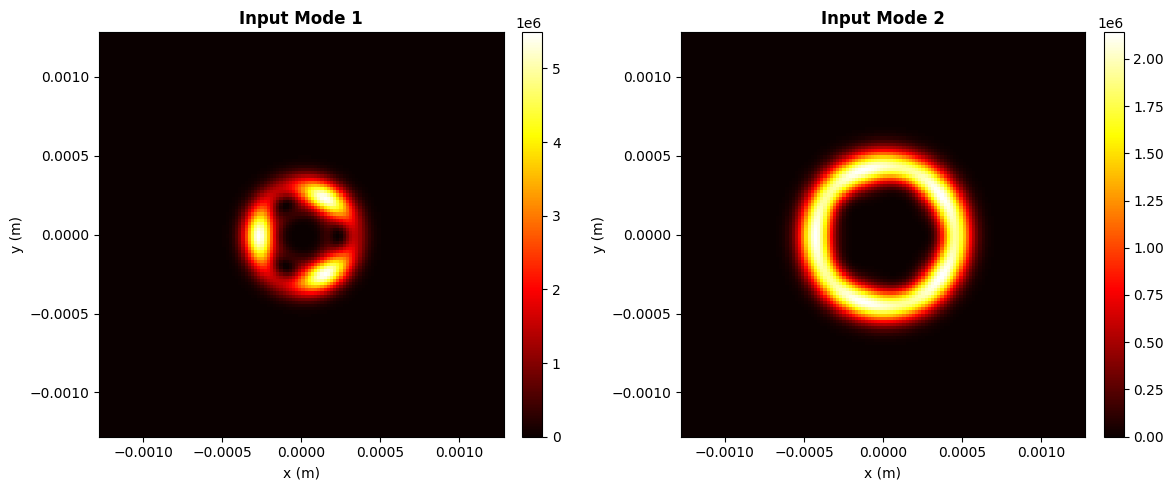

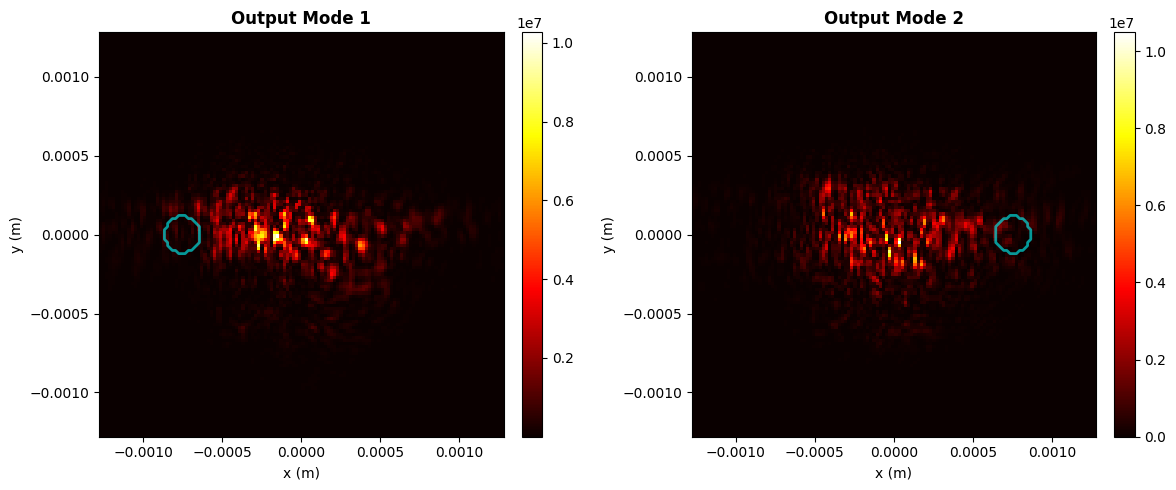

((<Figure size 1200x500 with 4 Axes>,
  array([<Axes: title={'center': 'Input Mode 1'}, xlabel='x (m)', ylabel='y (m)'>,
         <Axes: title={'center': 'Input Mode 2'}, xlabel='x (m)', ylabel='y (m)'>],
        dtype=object)),
 (<Figure size 1200x500 with 4 Axes>,
  array([<Axes: title={'center': 'Output Mode 1'}, xlabel='x (m)', ylabel='y (m)'>,
         <Axes: title={'center': 'Output Mode 2'}, xlabel='x (m)', ylabel='y (m)'>],
        dtype=object)))

In [14]:
# Visualize all input and output fields in separate figures
# To save the plots, provide a save_path parameter (without _inputs/_outputs suffix):
# visualize_input_output_fields(phase_maps, list_of_OAMs, save_path='plots/fields')
# This will create: 'plots/fields_inputs.png' and 'plots/fields_outputs.png'
visualize_input_output_fields(phase_maps, list_of_OAMs, save_path=f'inputs_outputs/january_13_2026/{instance_name}')

In [15]:
sort_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_OAMs)
print(crosstalk_matrix)

[[0.01164342 0.01739031]
 [0.00557081 0.01639873]]


Plot the crosstalk matrix

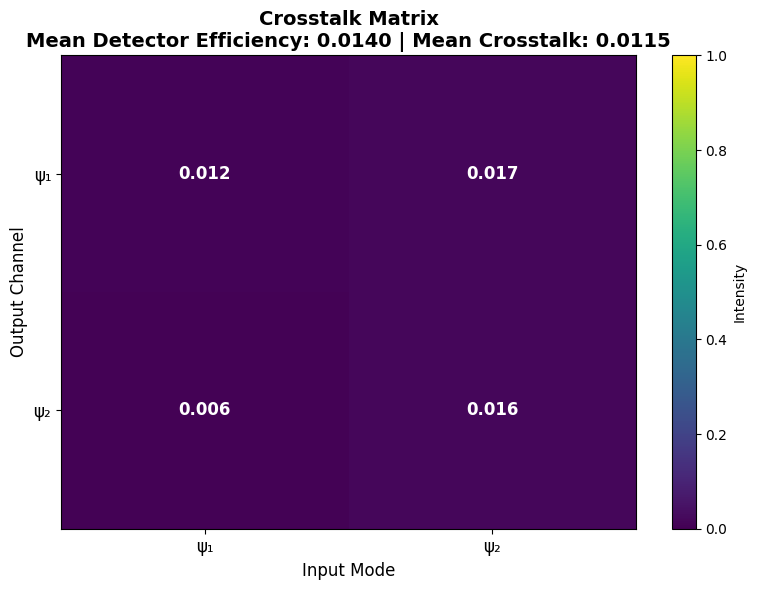

[[0.01164342 0.01739031]
 [0.00557081 0.01639873]]
Mean Detector Efficiency: 0.0140
Mean Crosstalk: 0.0115


In [16]:
# Compute mean detector efficiency (diagonal elements)
diagonal_mean = np.mean(np.diag(crosstalk_matrix))

# Compute mean crosstalk (off-diagonal elements)
if num_of_output_chans == 2:
    crosstalk_mean = np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]])
elif num_of_output_chans == 3:
    off_diagonal = [crosstalk_matrix[i,j] for i in range(3) for j in range(3) if i != j]
    crosstalk_mean = np.mean(off_diagonal)
else:
    off_diagonal = [crosstalk_matrix[i,j] for i in range(num_of_output_chans) for j in range(num_of_output_chans) if i != j]
    crosstalk_mean = np.mean(off_diagonal)

plt.figure(figsize=(8, 6))
plt.imshow(crosstalk_matrix, vmin=0.0, vmax=1.0, cmap='viridis', aspect='auto')
plt.colorbar(label='Intensity')
plt.title(f'Crosstalk Matrix\nMean Detector Efficiency: {diagonal_mean:.4f} | Mean Crosstalk: {crosstalk_mean:.4f}', 
          fontsize=14, fontweight='bold')

# Add text annotations showing the values in each cell
for i in range(num_of_output_chans):
    for j in range(num_of_output_chans):
        text_color = 'white' if crosstalk_matrix[i, j] < 0.5 else 'black'
        plt.text(j, i, f'{crosstalk_matrix[i, j]:.3f}', 
                ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

# Create axis labels based on number of output channels
if num_of_output_chans == 2:
    labels = ['ψ₁', 'ψ₂']
elif num_of_output_chans == 3:
    labels = ['ψ₁', 'ψ₂', 'ψ₃']
else:
    labels = [f'ψ₊{i+1}' for i in range(num_of_output_chans)]

plt.xticks(range(num_of_output_chans), labels, fontsize=12)
plt.yticks(range(num_of_output_chans), labels, fontsize=12)
plt.xlabel('Input Mode', fontsize=12)
plt.ylabel('Output Channel', fontsize=12)
plt.tight_layout()
plt.show()

print(crosstalk_matrix)
print(f"Mean Detector Efficiency: {diagonal_mean:.4f}")
print(f"Mean Crosstalk: {crosstalk_mean:.4f}")


# Effect of Rotation on Hologram 

In [167]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses = []

mode=0

for angle in rotate_angles: 
    # Generate the rotated fields
    list_of_rotated_OAMs = create_rotated_knots(angle)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_rotated_OAMs)
    
    # Report the mean on the detector efficency, crosstalk. 
    #mean_eff = np.mean([crosstalk_matrix[0,0], crosstalk_matrix[1,1]])
    #mean_cross = np.mean([crosstalk_matrix[1,0], crosstalk_matrix[0,1]])
    
    mean_eff = crosstalk_matrix[mode,mode]
    mean_cross = crosstalk_matrix[mode,(mode+1)%2]
    
    mean_effs.append(mean_eff)
    mean_crosses.append(mean_cross)

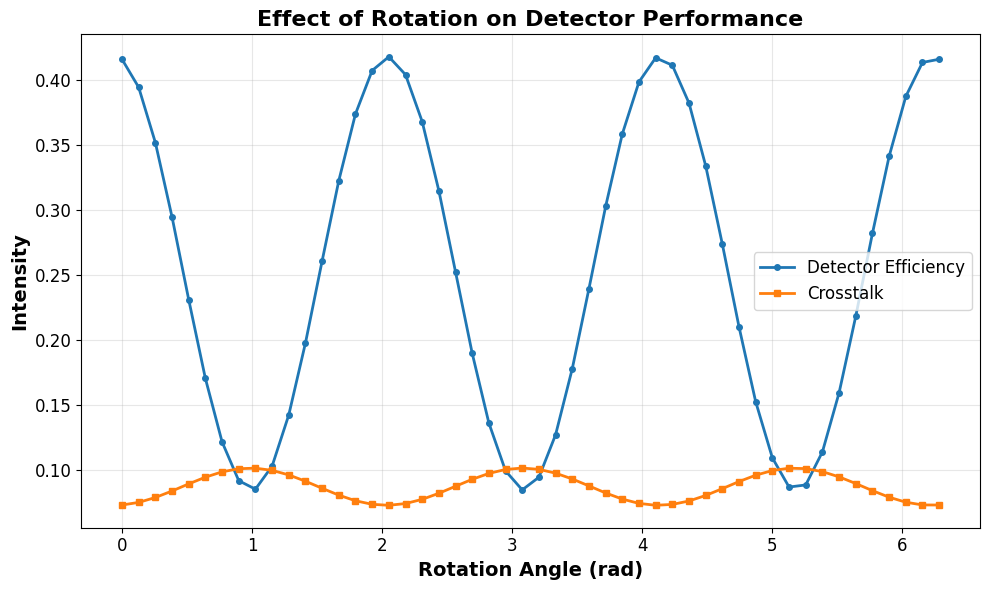

In [168]:
plt.figure(figsize=(10, 6))
plt.plot(rotate_angles, mean_effs, linewidth=2, label='Detector Efficiency', marker='o', markersize=4)
plt.plot(rotate_angles, mean_crosses, linewidth=2, label='Crosstalk', marker='s', markersize=4)
plt.xlabel('Rotation Angle (rad)', fontsize=14, fontweight='bold')
plt.ylabel('Intensity', fontsize=14, fontweight='bold')
plt.title('Effect of Rotation on Detector Performance', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

# Effect of Translation on Field Performance

In [154]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=50)

effs = []
crosses = []

effs_mode = []
cross_mode = []

mode=1

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 
for x_trans in x_translate:
    eff_row = []
    cross_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans)
        
        # Compute the crosstalk matrix
        sorting_performance, crosstalk_matrix, _ = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,mode])
        cross_row.append(crosstalk_matrix[mode, (mode+1)%2])
    
    effs.append(eff_row)
    crosses.append(cross_row)
    

Make a cool 3D plot because everyone likes 3D plots boy howdy

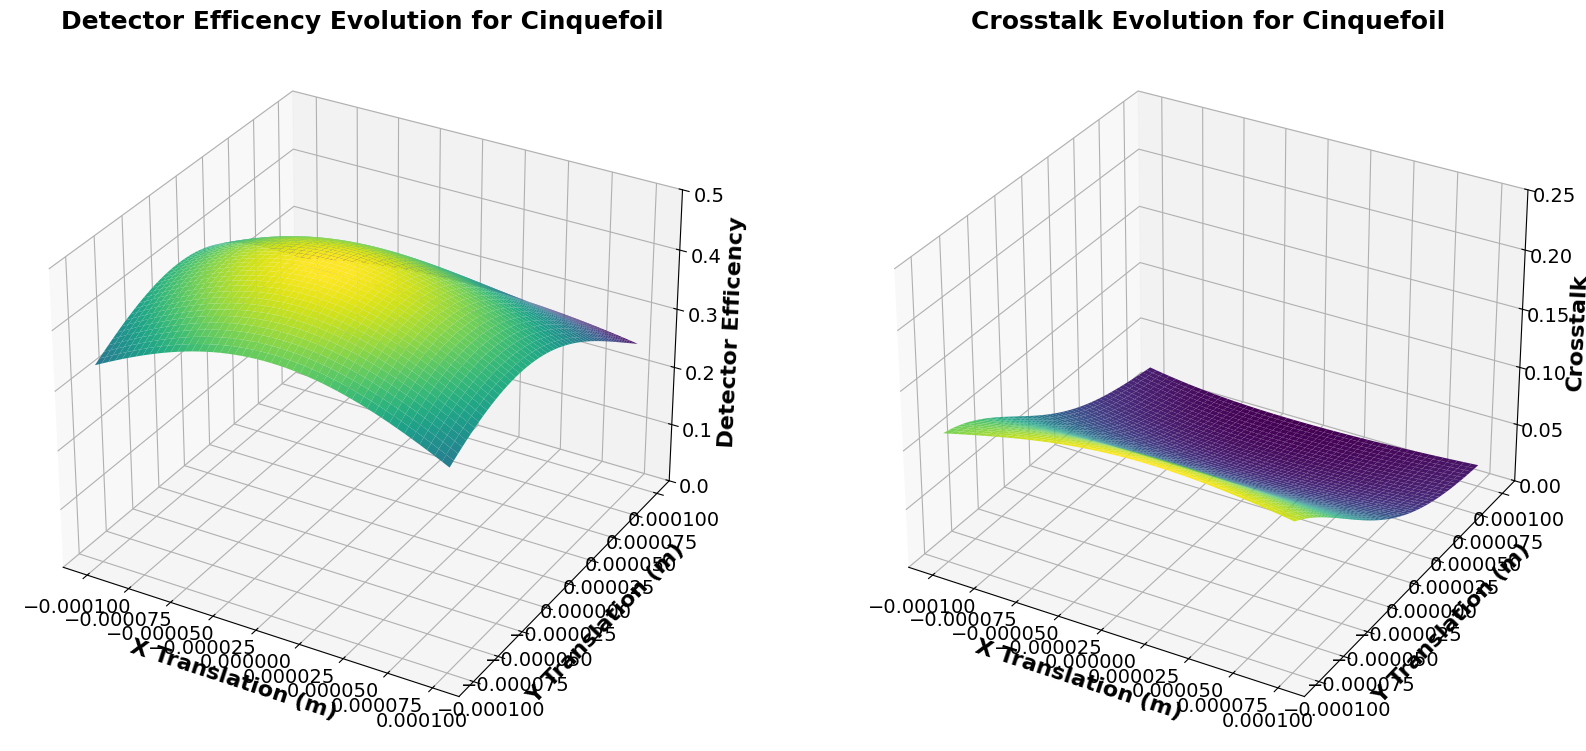

In [155]:
from mpl_toolkits.mplot3d import Axes3D

X_trans, Y_trans = np.meshgrid(x_translate, y_translate)
mode_name = ''

if mode==0:
    mode_name = 'Trefoil'
else:
    mode_name = 'Cinquefoil'

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X_trans, Y_trans, np.array(effs), cmap='viridis')
ax.set_xlabel('X Translation (m)', fontsize=16, fontweight='bold')
ax.set_ylabel('Y Translation (m)', fontsize=16, fontweight='bold')
ax.set_zlabel('Detector Efficency', fontsize=16, fontweight='bold')
ax.set_title(f'Detector Efficency Evolution for {mode_name}', fontsize=18, fontweight='bold')
ax.set_zlim([0, 0.5])
ax.tick_params(axis='both', which='major', labelsize=14)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_trans, Y_trans, np.array(crosses), cmap='viridis')
ax2.set_xlabel('X Translation (m)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Y Translation (m)', fontsize=16, fontweight='bold')
ax2.set_zlabel('Crosstalk', fontsize=16, fontweight='bold')
ax2.set_title(f'Crosstalk Evolution for {mode_name}', fontsize=18, fontweight='bold')
ax2.set_zlim([0, 0.25])
ax2.tick_params(axis='both', which='major', labelsize=14)